# Predicted dolomite surface charge — surface complexation model (SCM)

This notebook applies the constant-capacitance surface complexation model of Pokrovsky et al. (1999)
to the base runs of this dataset (vessel C, pH > 7) and **predicts** the net surface charge σ_T.

This is different from the measured σ_T (Pokrovsky Eqn 1, the charge-sum difference between the A+B
reference and vessel C). Here σ_T is a forward prediction from six intrinsic surface reactions on the
carbonate and metal sites, solved together with the surface potential (constant-capacitance layer).

Inputs per run: the calculated pH of vessel C and its measured Ca, Mg and Cl; the carbonate is set by
the open system (atmospheric pCO₂ = 10⁻³·⁵ atm). Intrinsic constants, site densities and the
capacitance model are those of the SCM, unchanged.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---- physical constants and SCM parameters (Pokrovsky et al., 1999) ----------
FARADAY = 96485.33212; GAS_CONSTANT = 8.31446261815324; TEMPERATURE_K = 298.15
F_OVER_RT = FARADAY / (GAS_CONSTANT * TEMPERATURE_K)
DAVIES_A, DAVIES_B = 0.5092, 0.3
LOG_K_HENRY, LOG_K_H2CO3 = -1.468, 16.681
T_CO3, T_CA, T_MG = 14.0e-6, 7.0e-6, 7.0e-6      # site densities, mol/m2
ALPHA = 0.004                                    # capacitance = sqrt(I)/ALPHA

# intrinsic log K of the six surface reactions (1..6) for Ca and Mg sites
LOG_K = {(1,"Ca"):-4.8,(1,"Mg"):-4.8,(2,"Ca"):-1.8,(2,"Mg"):-2.0,(3,"Ca"):-12.0,(3,"Mg"):-12.0,
         (4,"Ca"):11.5,(4,"Mg"):10.6,(5,"Ca"):24.0,(5,"Mg"):23.5,(6,"Ca"):16.6,(6,"Mg"):15.4}

AQUEOUS = {"OH-":(-1,{"H":-1},-13.997),"HCO3-":(-1,{"H":1,"CO3":1},10.329),
    "H2CO3*":(0,{"H":2,"CO3":1},16.681),"CaHCO3+":(1,{"H":1,"Ca":1,"CO3":1},11.435),
    "CaCO3":(0,{"Ca":1,"CO3":1},3.224),"CaOH+":(1,{"H":-1,"Ca":1},-12.780),
    "MgHCO3+":(1,{"H":1,"Mg":1,"CO3":1},11.399),"MgCO3":(0,{"Mg":1,"CO3":1},2.980),
    "MgOH+":(1,{"H":-1,"Mg":1},-11.440),"NaHCO3":(0,{"H":1,"CO3":1,"Na":1},10.079),
    "NaCO3-":(-1,{"CO3":1,"Na":1},1.270),"NaOH":(0,{"H":-1,"Na":1},-14.180)}
COMPONENT_CHARGE = {"H":1,"Ca":2,"Mg":2,"CO3":-2,"Na":1}
CHARGES = {**COMPONENT_CHARGE, **{k:v[0] for k,v in AQUEOUS.items()}, "Cl-":-1}

In [2]:
def davies_gamma(charge, I):
    if charge == 0: return 1.0
    r = np.sqrt(I)
    return 10.0**(-DAVIES_A*charge**2*(r/(1.0+r) - DAVIES_B*I))

def complexes_from_components(fa, I):
    out = {}
    for name,(ch,st,lk) in AQUEOUS.items():
        la = lk + sum(n*np.log10(fa[c]) for c,n in st.items())
        out[name] = 10.0**la / davies_gamma(ch, I)
    return out

def component_totals(fc, cx):
    t = dict(fc)
    for name,(_c,st,_l) in AQUEOUS.items():
        for comp,n in st.items(): t[comp] += n*cx[name]
    return t

def speciate(pH, ca_tot, mg_tot, nacl, sum_co2=None, pco2=None,
             max_outer=200, exponent=0.7, tol=1e-14):
    if (sum_co2 is None) == (pco2 is None): raise ValueError("give one of sum_co2/pco2")
    a_h = 10.0**-pH; ionic = max(nacl,1e-6); na_tot, cl_tot = max(nacl,1e-30), nacl
    targets = {"Ca":ca_tot,"Mg":mg_tot,"Na":na_tot}
    if sum_co2 is not None: targets["CO3"] = sum_co2
    fc = {"H":a_h,"Ca":max(ca_tot,1e-12),"Mg":max(mg_tot,1e-12),
          "CO3":1e-2*max(sum_co2 or 1e-8,1e-12),"Na":na_tot}
    for _ in range(max_outer):
        g1,g2 = davies_gamma(1,ionic), davies_gamma(2,ionic); fc["H"] = a_h/g1
        if pco2 is not None:
            fc["CO3"] = 10.0**(LOG_K_HENRY+np.log10(pco2)-LOG_K_H2CO3)/a_h**2/g2
        step, prev = exponent, None
        for _s in range(2000):
            fa = {"H":a_h,"Ca":fc["Ca"]*g2,"Mg":fc["Mg"]*g2,"CO3":fc["CO3"]*g2,"Na":fc["Na"]*g1}
            cx = complexes_from_components(fa, ionic); tot = component_totals(fc, cx)
            worst = max(abs(tot[k]/v-1.0) for k,v in targets.items() if v>0)
            if worst < tol: break
            if prev is not None and worst > prev: step = max(step/2.0,1e-3)
            prev = worst
            for comp,tg in targets.items():
                if tg > 0: fc[comp] *= (tg/tot[comp])**step
        else: raise RuntimeError(f"mass balance did not close at pH {pH}")
        conc = {**fc,**cx,"Cl-":cl_tot}
        ni = 0.5*sum(conc[n]*CHARGES[n]**2 for n in conc)
        done = abs(ni-ionic) < 1e-13*ionic; ionic = ni
        if done: break
    return {"pH":pH,"ionic_strength":ionic,"conc":conc,"free_activity":fa,"totals":tot}

In [3]:
POSITIVE = (">CaOH2+",">MgOH2+",">CO3Ca+",">CO3Mg+")
NEGATIVE = (">CO3-",">CaCO3-",">MgCO3-",">CaO-",">MgO-")

def surface_at_potential(psi0, a_h, a_ca, a_mg, a_co3):
    f = np.exp(-F_OVER_RT*psi0)                     # Boltzmann factor
    r_d  = 10.0**LOG_K[(1,"Ca")]/(f*a_h)
    r_ca = 10.0**LOG_K[(2,"Ca")]*f*a_ca/a_h
    r_mg = 10.0**LOG_K[(2,"Mg")]*f*a_mg/a_h
    x = T_CO3/(1.0+r_d+r_ca+r_mg)                   # carbonate site balance
    out = {">CO3H":x,">CO3-":x*r_d,">CO3Ca+":x*r_ca,">CO3Mg+":x*r_mg}
    for metal,total in (("Ca",T_CA),("Mg",T_MG)):
        r_o   = 10.0**LOG_K[(3,metal)]/(f*a_h)
        r_oh2 = 10.0**LOG_K[(4,metal)]*f*a_h
        r_hco3= 10.0**LOG_K[(5,metal)]*a_co3*a_h**2
        r_co3 = 10.0**LOG_K[(6,metal)]*a_co3*a_h/f
        x = total/(1.0+r_o+r_oh2+r_hco3+r_co3)      # metal site balance
        out[f">{metal}OH"]=x; out[f">{metal}O-"]=x*r_o; out[f">{metal}OH2+"]=x*r_oh2
        out[f">{metal}HCO3"]=x*r_hco3; out[f">{metal}CO3-"]=x*r_co3
    return out

def net_charge(s): return sum(s[k] for k in POSITIVE) - sum(s[k] for k in NEGATIVE)

def solve_surface(a_h, a_ca, a_mg, a_co3, I, capacitance=None,
                  relaxation=0.3, tolerance=1e-15, max_iterations=4000):
    if capacitance is None: capacitance = np.sqrt(I)/ALPHA
    psi0, prev = 0.0, None
    for it in range(1, max_iterations+1):
        s = surface_at_potential(psi0, a_h, a_ca, a_mg, a_co3)
        ch = net_charge(s)*FARADAY/capacitance - psi0
        if prev is not None and (abs(ch) > abs(prev) or ch*prev < 0):
            relaxation = max(relaxation/2.0, 1e-4)
        prev = ch; psi0 += relaxation*ch
        if abs(relaxation*ch) < tolerance: break
    else: raise RuntimeError("surface potential did not converge")
    s = surface_at_potential(psi0, a_h, a_ca, a_mg, a_co3)
    return {"psi0":psi0,"capacitance":capacitance,"sigma_T":net_charge(s),"surface":s}

def solve_point(pH, ca_tot, mg_tot, nacl, sum_co2=None, pco2=None, capacitance=None):
    aq = speciate(pH, ca_tot, mg_tot, nacl, sum_co2=sum_co2, pco2=pco2); a = aq["free_activity"]
    return {"aqueous":aq, **solve_surface(a["H"],a["Ca"],a["Mg"],a["CO3"],
                                          aq["ionic_strength"], capacitance=capacitance)}

## Data — vessel C base runs (pH > 7)

Calculated pH of vessel C and its measured Ca, Mg, Na and Cl (mg/L). The carbonate is set by the open
system (atmospheric pCO₂). The measured σ_T from Eqn 1 is carried alongside for comparison.

In [4]:
MW = dict(Ca=40.078, Mg=24.305, Na=22.99, Cl=35.453, CO3=60.009, HCO3=61.017)

# run, calc pH_C, Ca, Mg, Na, Cl, CO3, HCO3 (mg/L), measured sigma_T (mmol/m2, Eqn 1)
data = [(5,7.792,37.2,24.4,16466.5,24244,18.2,106.1,-0.02571),
        (6,8.482,15.6,13.6,16183.2,23699,92.8,  7.2, 0.04720),
        (7,8.600,16.3, 4.4,14759.0,21815,120.2, 0.0, 0.07232),
        (8,8.630,17.0, 3.6,16450.8,24118,134.0, 0.0, 0.07046),
        (9,8.648, 9.8, 1.0,15393.8,22678,136.4, 0.0, 0.08602)]

rows = []
for run,pH,Ca,Mg,Na,Cl,CO3,HCO3,meas in data:
    ca = Ca/1e3/MW["Ca"]; mg = Mg/1e3/MW["Mg"]; cl = Cl/1e3/MW["Cl"]
    p = solve_point(pH, ca_tot=ca, mg_tot=mg, nacl=cl, pco2=10**-3.5)   # open system
    rows.append({"run":run, "pH":pH, "I":p["aqueous"]["ionic_strength"],
                 "psi0_mV":p["psi0"]*1e3,
                 "sigma_T predicted (mmol/m2)": p["sigma_T"]*1e3,
                 "sigma_T measured (mmol/m2)": meas})
pred = pd.DataFrame(rows).set_index("run")
print(pred.to_string(float_format=lambda v: f"{v:.4g}"))

       pH      I  psi0_mV  sigma_T predicted (mmol/m2)  sigma_T measured (mmol/m2)
run                                                                               
5   7.792 0.6879    2.255                     0.004846                    -0.02571
6   8.482 0.6712   -4.267                    -0.009059                      0.0472
7     8.6 0.6177   -6.128                     -0.01248                     0.07232
8    8.63 0.6827   -6.124                     -0.01311                     0.07046
9   8.648 0.6417   -7.337                     -0.01523                     0.08602


## Predicted surface charge vs pH (line), with the measured points

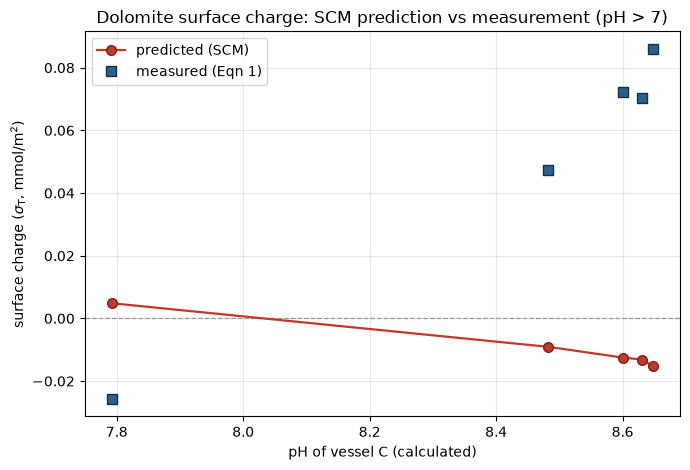

In [5]:
sp = pred.sort_values("pH")
fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.axhline(0, color="0.6", lw=0.9, ls="--")
ax.plot(sp["pH"], sp["sigma_T predicted (mmol/m2)"], "-o", color="#c0392b",
        markeredgecolor="#7b241c", lw=1.6, ms=7, zorder=3, label="predicted (SCM)")
ax.plot(sp["pH"], sp["sigma_T measured (mmol/m2)"], "s", color="#2c5f8a",
        markeredgecolor="#12314a", ms=7, zorder=3, label="measured (Eqn 1)")
ax.set_xlabel("pH of vessel C (calculated)")
ax.set_ylabel(r"surface charge ($\sigma_\mathrm{T}$, mmol/m$^2$)")
ax.set_title("Dolomite surface charge: SCM prediction vs measurement (pH > 7)")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

## Notes

1. **Predicted, not measured.** These σ_T come from the forward SCM (six intrinsic surface reactions,
   constant-capacitance layer, site densities T_CO3 = 14, T_Ca = T_Mg = 7 µmol/m²). The aqueous
   speciation inside the SCM uses its own database and the Davies model (b = 0.3).
2. **pzc near pH 7.8.** The prediction crosses zero close to pH 7.8 and turns negative with rising pH,
   the trend Pokrovsky et al. (1999) report for dolomite.
3. **Sign versus the measurement.** The measured σ_T (Eqn 1) is positive and rising on these base runs,
   opposite to the SCM trend. That disagreement is real and worth examining: the measurement carries
   the dissolution-driven Ca/Mg release of vessel C, while the SCM assumes fixed site densities and no
   dissolution. The two are answering slightly different questions.
4. **Open system.** Carbonate is fixed by atmospheric pCO₂ (10⁻³·⁵ atm); passing the measured total
   carbon instead (sum_co2) shifts the predicted values only slightly.

Reference: Pokrovsky, O. S., Schott, J., Thomas, F. (1999). Geochim. Cosmochim. Acta 63, 3133–3143.